In [146]:
import numpy as np

import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
import pandas as pd
from matplotlib import pyplot as plt

from causal_graph_comparison.subsample import subsample_outputs
from causal_graph_comparison import *

from climatem.data_loader.causal_datamodule import CausalClimateDataModule
import torch

from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.parcorr_wls import ParCorrWLS
from tigramite.independence_tests.gsquared import Gsquared
from tigramite.independence_tests.regressionCI import RegressionCI


Taken from https://github.com/jakobrunge/tigramite/blob/master/tutorials/causal_discovery/tigramite_tutorial_pcmciplus.ipynb

In [147]:
# Parameters

N_MODES = 4
TAU_MAX = 5
LAT = 40
LON = 40
N_SAMPLES = 995

In [148]:
# Test settings
TEST_BATCH_SIZE = 1
NO_ACCEL = False
SEED = 1
FUTURE_TIMESTEPS = 1
ROLLOUT_TIMESTEPS = 50
LONGITUDE = 40
LATITUDE = 40
TAU = 5
LAYERS = [1600, 800, 1600]
INPUT_SIZE = LATITUDE * LONGITUDE * TAU
OUTPUT_SIZE = LATITUDE * LONGITUDE * FUTURE_TIMESTEPS

# Load data
dl = CausalClimateDataModule(
    # Required parameters for ClimateDataModule
    in_var_ids=["savar"],
    out_var_ids=["savar"],  # Same as input for SAVAR
    train_years="2015-2100",
    train_historical_years="1950-2014",
    test_years="2015-2100",  # Same as train for SAVAR
    val_split=0.1,  # 10% validation split
    seq_to_seq=True,
    channels_last=False,
    train_scenarios=["savar"],
    test_scenarios=["savar"],
    train_models="savar",
    eval_batch_size=64,
    num_workers=0,
    pin_memory=False,
    load_train_into_mem=True,
    load_test_into_mem=True,
    verbose=True,
    seed=42,
    seq_len=12,
    data_dir="",  # Not used for SAVAR
    output_save_dir=f"{SCRATCH_DIR}/data/SAVAR_DATA_TEST",
    num_ensembles=1,
    lon=LONGITUDE,
    lat=LATITUDE,
    num_levels=1,
    global_normalization=True,
    seasonality_removal=False,
    reload_climate_set_data=True,
    # Required parameters for CausalClimateDataModule
    tau=TAU,
    future_timesteps=FUTURE_TIMESTEPS,
    num_months_aggregated=1,
    train_val_interval_length=100,
    # SAVAR specific parameters
    time_len=10000,
    comp_size=10,
    noise_val=0.2,
    n_per_col=2,
    difficulty="med_easy",
    seasonality=False,
)

dl.setup()

test_dataset = dl._data_val

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

Test models: None
TEST SET NAMES ['ssp370_NorESM2-LM', 'ssp126_NorESM2-LM']
2015-2100
1950-2014
Getting causal data [mode=train+val] ...
Loaded data shape: (1600, 10000)
Loaded data shape after: (10000, 40, 40)
data is float32
Trying to regrid to lon, lat if we have regular data...
intervallength100
datashape10000
train: float32


In [149]:
data, target = next(iter(test_loader))
print("Data shape: ", data.shape)
print("Target shape: ", target.shape)

target_list = []
for i, (data, target) in enumerate(test_loader):
        target_list.append(target.squeeze().cpu().numpy())

targets_1000 = np.array(target_list)

print("Shape of targets for 1000 time steps: ", targets_1000.shape)

Data shape:  torch.Size([1, 5, 1, 1600])
Target shape:  torch.Size([1, 1, 1, 1600])
Shape of targets for 1000 time steps:  (999, 1600)


In [150]:
# Step 1: Load the data
mlp_output = np.load("../outputs/test_results-mlp-savar.npz")

targets_50 = mlp_output["target"]
print("MLP target shape for 50 time steps: ", targets_50.shape)


MLP target shape for 50 time steps:  (50, 1600)


In [151]:
# Spatial subsampling of outputs for dimensionality reduction
subsampled_targets_50 = subsample_outputs(targets_50, N_MODES)
subsampled_targets_1000 = subsample_outputs(targets_1000, N_MODES)

print("Subsampled targets 50 shape: ", subsampled_targets_50.shape)
print("Subsampled targets 1000 shape: ", subsampled_targets_1000.shape)

Subsampled shape:  (50, 2, 2)
Subsampled shape:  (999, 2, 2)
Subsampled targets 50 shape:  (50, 2, 2)
Subsampled targets 1000 shape:  (999, 2, 2)


In [152]:
test_100 = subsampled_targets_1000[:99, :, :]

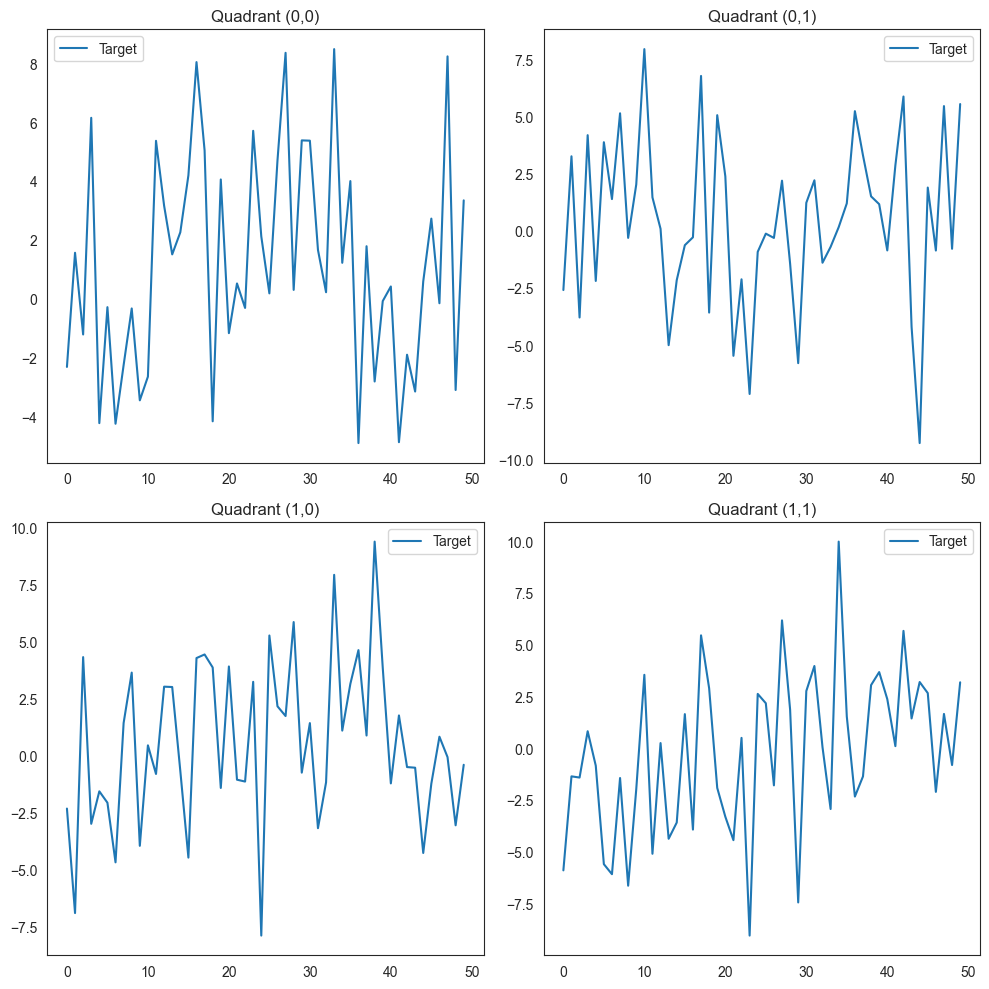

Subsampled targets shape:  (50, 2, 2)


In [153]:
# Plot targets and outputs for all 4 quadrants for 50 time steps
plt.figure(figsize=(10, 10))

for i in range(2):
    for j in range(2):
        plt.subplot(2, 2, i*2 + j + 1)
        test_targets = subsampled_targets_50[:, i, j]
        
        plt.plot(test_targets, label="Target")
        plt.title(f"Quadrant ({i},{j})")
        plt.legend()

plt.tight_layout()
plt.show()

print("Subsampled targets shape: ", subsampled_targets_50.shape)


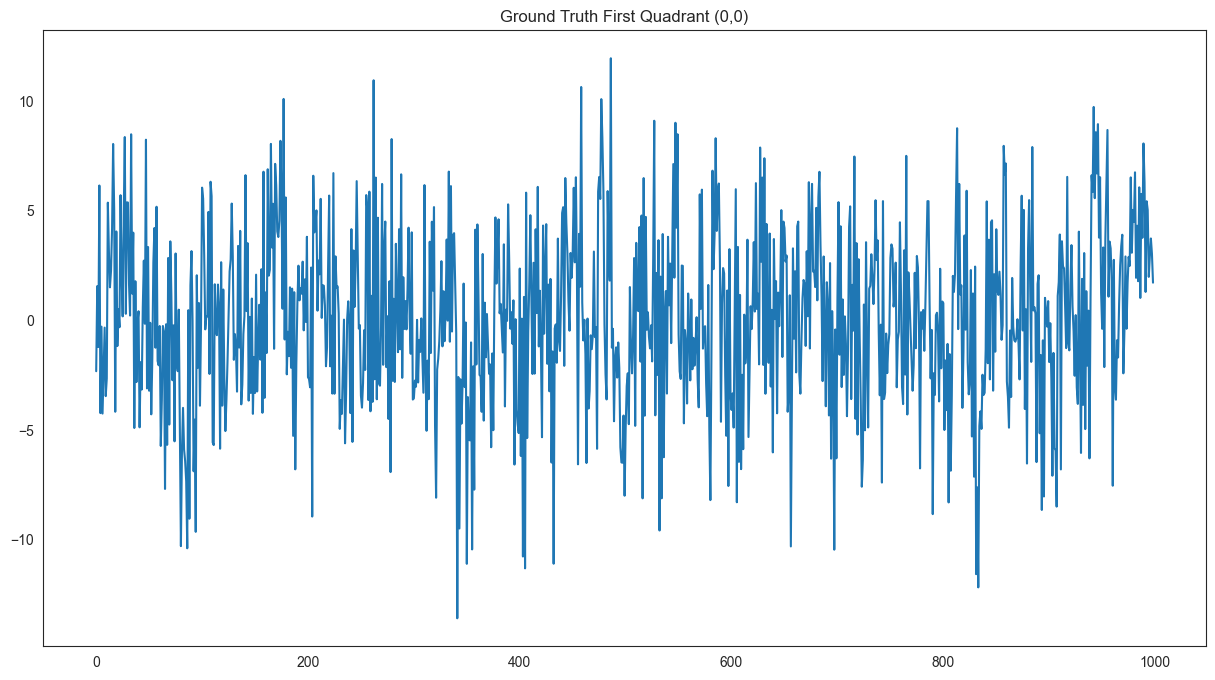

In [154]:
# Plot ground truth data for one quadrant 1000 time steps
plt.figure(figsize=(15, 8))
gt_data = subsampled_targets_1000[:, 0, 0]  # First quadrant
plt.plot(gt_data)
plt.title("Ground Truth First Quadrant (0,0)")
plt.show()



In [155]:
# STEP 4: Learn causal graph using PCMCI+

# flatten the data
flat_targets_50 = subsampled_targets_50.reshape(subsampled_targets_50.shape[0], -1)
flat_targets_1000 = subsampled_targets_1000.reshape(subsampled_targets_1000.shape[0], -1)
flat_targets_100 = test_100.reshape(test_100.shape[0], -1)

# Create variable names for the modes
var_names = [f"mode_{i}" for i in range(N_MODES)]
dataframe = pp.DataFrame(flat_targets_50, var_names=var_names)

# Initialize PCMCI+
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=GPDC(),
    # cond_ind_test=ParCorr(),
    verbosity=2
)

# Run PCMCI+
results = pcmci.run_pcmciplus(
    tau_max=TAU_MAX,  # Maximum time lag
    tau_min=1,
    # pc_alpha=[0.0001, 0.01, 0.1, 0.5],  # Significance level
    # pc_alpha=0.5,
    pc_alpha=0.1,
)

n_gt_connections = 8 # TODO: get this from the GT causal graph in parameters csv file

# Extract results
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = gp_dc
tau_min = 1
tau_max = 5
pc_alpha = [0.1]
max_conds_dim = None
max_combinations = 1



## Variable mode_0

Iterating through pc_alpha = [0.1]:

# pc_alpha = 0.1 (1/1):

Testing condition sets of dimension 0:

    Link (mode_0 -1) -?> mode_0 (1/20):
    Subset 0: () gives pval = 0.98400 / val =  0.161
    Non-significance detected.

    Link (mode_0 -2) -?> mode_0 (2/20):
    Subset 0: () gives pval = 0.14200 / val =  0.317
    Non-significance detected.

    Link (mode_0 -3) -?> mode_0 (3/20):
    Subset 0: () gives pval = 0.38600 / val =  0.252
    Non-significance detected.

    Link (mode_0 -4) -?> mode_0 (4/20):
    Subset 0: () gives pval = 0.31200 / val =  0.268
    Non-significance detected.

    Link (mode_0 -5) -?> mode_0 (5/20):
    Subset 0: () gives pval = 0.50400 / val =  0.234
    Non-significance detected.

    Link (mode_1 -1) -?> mode_0 (6/20):
    Subset 0: () gives p

In [157]:
print("flat_targets_50.shape: ", flat_targets_50.shape)
print("flat_targets_1000.shape: ", flat_targets_1000.shape)
print("flat_targets_100.shape: ", flat_targets_100.shape)

print("dataframe.M: ", dataframe.M)
print("dataframe.N: ", dataframe.N)
print("dataframe.T: ", dataframe.T)

flat_targets_50.shape:  (50, 4)
flat_targets_1000.shape:  (999, 4)
flat_targets_100.shape:  (99, 4)
dataframe.M:  1
dataframe.N:  4
dataframe.T:  {0: 50}


In [159]:
flat_targets_50

array([[-2.31844139, -2.59508801, -2.32765293, -5.89805174],
       [ 1.56032467,  3.25435042, -6.9163413 , -1.35799146],
       [-1.21586585, -3.79617858,  4.32347298, -1.41597223],
       [ 6.14607048,  4.17827511, -2.99582505,  0.82170683],
       [-4.22823   , -2.19796467, -1.57073426, -0.84145117],
       [-0.28781188,  3.86994123, -2.07027102, -5.59872818],
       [-4.24909306,  1.3835398 , -4.68853807, -6.08346319],
       [-2.25722885,  5.13546944,  1.42990541, -1.43832958],
       [-0.3316949 , -0.31400314,  3.64272666, -6.6391449 ],
       [-3.45360494,  2.02208471, -3.96358395, -1.97991228],
       [-2.64861012,  7.94249582,  0.4499093 ,  3.54562473],
       [ 5.36441517,  1.45710707, -0.80888975, -5.09716702],
       [ 3.15993404,  0.08347788,  3.0255003 ,  0.24930328],
       [ 1.50508881, -5.00638199,  3.0099864 , -4.37218142],
       [ 2.25561786, -2.16136003, -0.67079574, -3.5887351 ],
       [ 4.19110394, -0.63384563, -4.48096991,  1.64704525],
       [ 8.03887844, -0.

In [158]:
dataframe.values

{0: array([[-2.31844139, -2.59508801, -2.32765293, -5.89805174],
        [ 1.56032467,  3.25435042, -6.9163413 , -1.35799146],
        [-1.21586585, -3.79617858,  4.32347298, -1.41597223],
        [ 6.14607048,  4.17827511, -2.99582505,  0.82170683],
        [-4.22823   , -2.19796467, -1.57073426, -0.84145117],
        [-0.28781188,  3.86994123, -2.07027102, -5.59872818],
        [-4.24909306,  1.3835398 , -4.68853807, -6.08346319],
        [-2.25722885,  5.13546944,  1.42990541, -1.43832958],
        [-0.3316949 , -0.31400314,  3.64272666, -6.6391449 ],
        [-3.45360494,  2.02208471, -3.96358395, -1.97991228],
        [-2.64861012,  7.94249582,  0.4499093 ,  3.54562473],
        [ 5.36441517,  1.45710707, -0.80888975, -5.09716702],
        [ 3.15993404,  0.08347788,  3.0255003 ,  0.24930328],
        [ 1.50508881, -5.00638199,  3.0099864 , -4.37218142],
        [ 2.25561786, -2.16136003, -0.67079574, -3.5887351 ],
        [ 4.19110394, -0.63384563, -4.48096991,  1.64704525],
     

In [ ]:
correlations = pcmci.run_bivci(tau_max=10, val_only=True)['val_matrix']
lag_func_matrix = tp.plot_lagfuncs(val_matrix=correlations, 
                                   setup_args={'var_names':var_names, 'figsize':(15, 10),
                                    'x_base':5, 'y_base':.5})

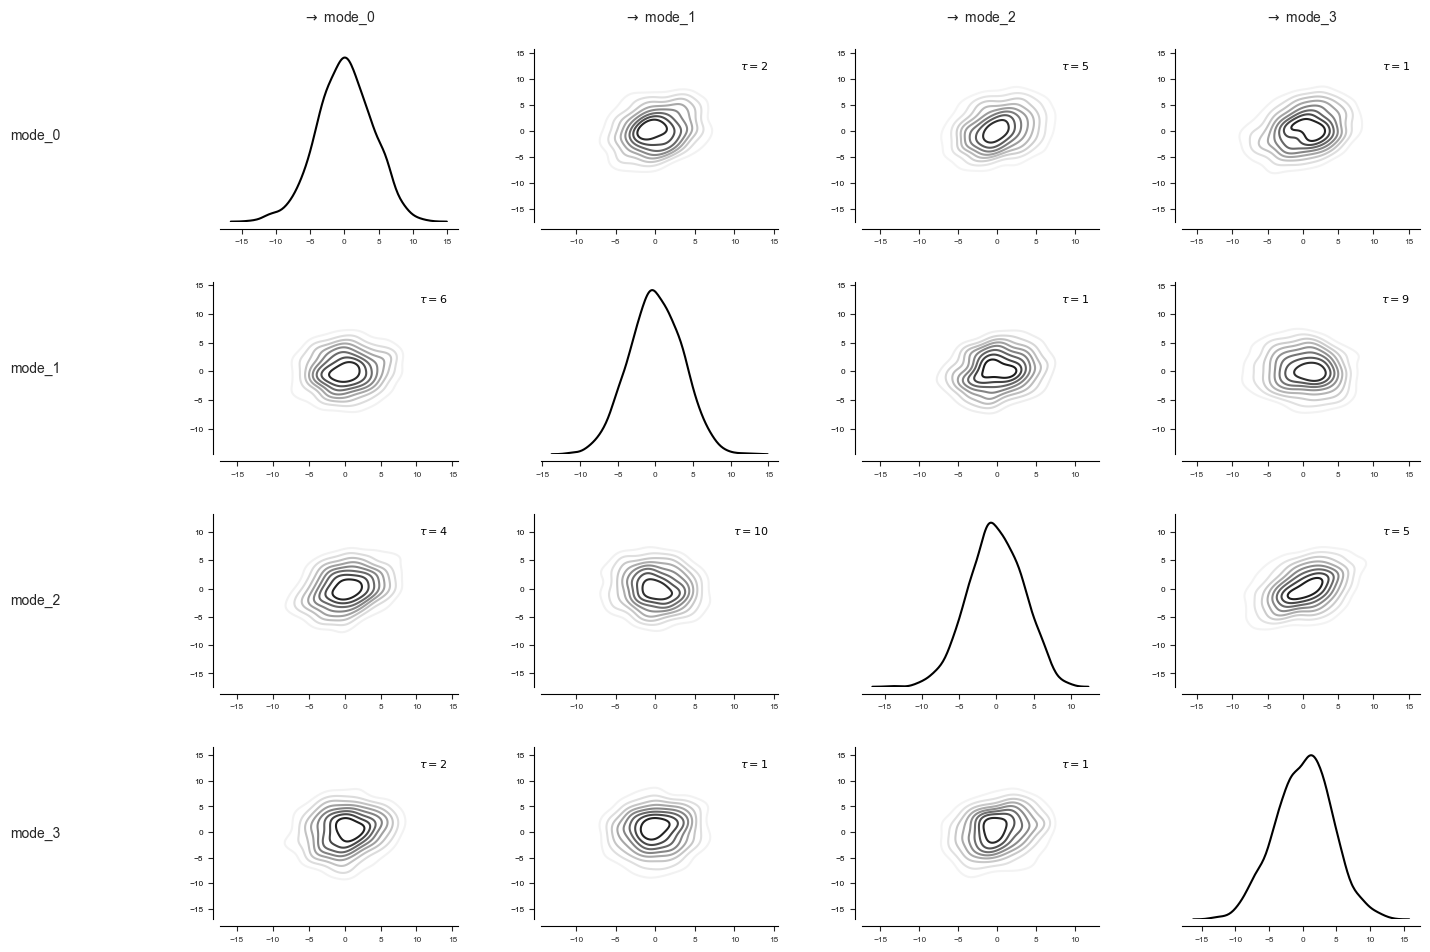

In [88]:
matrix_lags = np.argmax(np.abs(correlations), axis=2)
tp.plot_densityplots(dataframe=dataframe, setup_args={'figsize':(15, 10)}, add_densityplot_args={'matrix_lags':matrix_lags}); plt.show()

In [142]:
# Keep only the top 2 incoming values for each mode
print(f"\nFiltering to keep only top 2 incoming values per mode...")

# Create a copy of the original val_matrix
filtered_val_matrix = val_matrix.copy()
filtered_graph = graph.copy()

# For each target mode (each of the 4 modes)
for target_mode in range(val_matrix.shape[0]):
    print(f"\nProcessing incoming connections to mode {target_mode}:")
    
    # Collect all incoming values to this target mode
    # We need row 'target_mode' from each of the 4 matrices
    incoming_values = []
    incoming_positions = []
    
    for source_mode in range(val_matrix.shape[0]):  # source modes
        for lag in range(val_matrix.shape[2]):      # time lags
            value = val_matrix[source_mode, target_mode, lag]
            if value != 0:  # Only consider non-zero values
                incoming_values.append(abs(value))
                incoming_positions.append((source_mode, target_mode, lag))
    
    # Find the top 2 incoming connections
    if len(incoming_values) > 0:
        # Get indices of top 2 values
        top_indices = np.argsort(incoming_values)[-2:]
        
        print(f"Top 2 incoming connections to mode {target_mode}:")
        for idx in top_indices:
            source_mode, target_mode, lag = incoming_positions[idx]
            value = val_matrix[source_mode, target_mode, lag]
            print(f"  From mode {source_mode} to mode {target_mode} at lag {lag}: {value:.6f}")
    
    # Create a mask for all incoming connections to this target mode
    # Set all incoming connections to this target mode to 0/empty first
    for source_mode in range(val_matrix.shape[0]):
        for lag in range(val_matrix.shape[2]):
            filtered_val_matrix[source_mode, target_mode, lag] = 0
            filtered_graph[source_mode, target_mode, lag] = ""
    
    # Then restore only the top 2 incoming connections
    if len(incoming_values) > 0:
        for idx in top_indices:
            source_mode, target_mode, lag = incoming_positions[idx]
            filtered_val_matrix[source_mode, target_mode, lag] = val_matrix[source_mode, target_mode, lag]
            filtered_graph[source_mode, target_mode, lag] = graph[source_mode, target_mode, lag]

print(f"\nFiltered val_matrix shape: {filtered_val_matrix.shape}")
print(f"Total non-zero values in filtered matrix: {np.sum(filtered_val_matrix != 0)}")

# Print the filtered graph to see the remaining links
print(f"\nFiltered graph:")
print(filtered_graph)


Filtering to keep only top 2 incoming values per mode...

Processing incoming connections to mode 0:
Top 2 incoming connections to mode 0:
  From mode 0 to mode 0 at lag 2: 0.448087
  From mode 1 to mode 0 at lag 1: 0.609162

Processing incoming connections to mode 1:
Top 2 incoming connections to mode 1:
  From mode 0 to mode 1 at lag 1: 0.274932
  From mode 2 to mode 1 at lag 5: 0.325907

Processing incoming connections to mode 2:
Top 2 incoming connections to mode 2:
  From mode 1 to mode 2 at lag 1: 0.282137
  From mode 1 to mode 2 at lag 4: 0.328885

Processing incoming connections to mode 3:
Top 2 incoming connections to mode 3:
  From mode 3 to mode 3 at lag 3: 0.256965
  From mode 0 to mode 3 at lag 5: 0.279506

Filtered val_matrix shape: (4, 4, 6)
Total non-zero values in filtered matrix: 8

Filtered graph:
[[['' '' '-->' '' '' '']
  ['' '-->' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '' '' '' '' '-->']]

 [['' '-->' '' '' '' '']
  ['' '' '' '' '' '']
  ['' '-->' '' '' '-->' '


Plotting filtered causal graph...


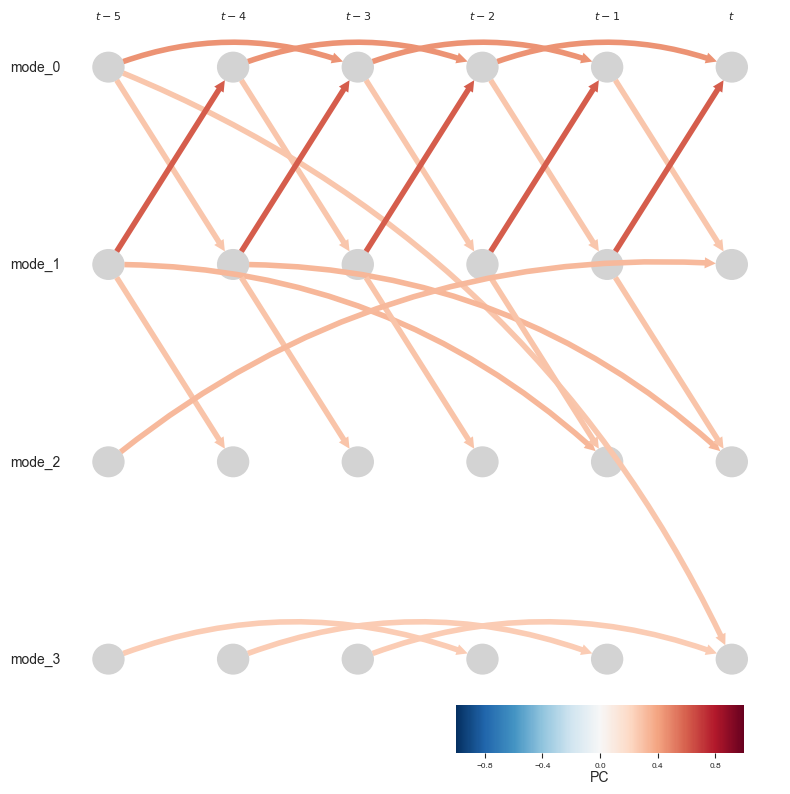

In [143]:
# Plot the filtered graph
print(f"\nPlotting filtered causal graph...")
tp.plot_time_series_graph(
    graph=filtered_graph,
    val_matrix=filtered_val_matrix,
    figsize=(8, 8),
    node_size=0.05,
    var_names=var_names,
    link_colorbar_label='PC')

plt.tight_layout()
plt.show()
plt.close()

In [104]:

print(f"\nPCMCI+ Results:")
print(f"Graph shape: {graph.shape}")
print(f"Value matrix shape: {val_matrix.shape}")
print(f"P-value matrix shape: {p_matrix.shape}")

# Print the discovered links
print(f"\nDiscovered causal links:")
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX):
            if graph[i, j, tau] != "":
                print(f"{var_names[i]} <-{graph[i, j, tau]}- {var_names[j]} (lag {tau+1})")


PCMCI+ Results:
Graph shape: (4, 4, 6)
Value matrix shape: (4, 4, 6)
P-value matrix shape: (4, 4, 6)

Discovered causal links:
mode_0 <--->- mode_0 (lag 3)
mode_0 <--->- mode_1 (lag 3)
mode_0 <--->- mode_3 (lag 2)
mode_2 <--->- mode_0 (lag 5)
mode_2 <--->- mode_2 (lag 4)
mode_3 <--->- mode_3 (lag 4)


In [105]:
# Step 5: Analyze mode relationships

print(f"\nStep 5: Analyzing mode relationships...")

# Calculate correlations between modes
correlations = np.corrcoef(subsampled_targets_1000.reshape(-1, 4).T)

print(f"\nCorrelation matrix between modes:")
print(pd.DataFrame(correlations, index=var_names, columns=var_names))

# Count causal links per mode
print(f"\nCausal link counts per mode:")
for i, mode in enumerate(var_names):
    incoming = np.sum(graph[i, :, :] != "")
    outgoing = np.sum(graph[:, i, :] != "")
    print(f"{mode}: {incoming} incoming, {outgoing} outgoing links")



Step 5: Analyzing mode relationships...

Correlation matrix between modes:
          mode_0    mode_1    mode_2    mode_3
mode_0  1.000000  0.161566  0.084923  0.093544
mode_1  0.161566  1.000000  0.031795  0.085001
mode_2  0.084923  0.031795  1.000000  0.033744
mode_3  0.093544  0.085001  0.033744  1.000000

Causal link counts per mode:
mode_0: 4 incoming, 2 outgoing links
mode_1: 0 incoming, 1 outgoing links
mode_2: 3 incoming, 2 outgoing links
mode_3: 1 incoming, 3 outgoing links


In [ ]:
val_matrix_filtered = val_matrix.copy()

val_matrix_filtered[val_matrix < threshold_value] = 0

print("val_matrix: ", val_matrix_filtered)